## Decision Tree classification:

In [14]:
from sklearn.datasets import load_iris
iris = load_iris()
X = iris.data[:, 2:]                    # 取所有行，第三列到最后一列（这个数据一共只有4列对应0123）这里后两列是petal length and petal width
y = iris.target

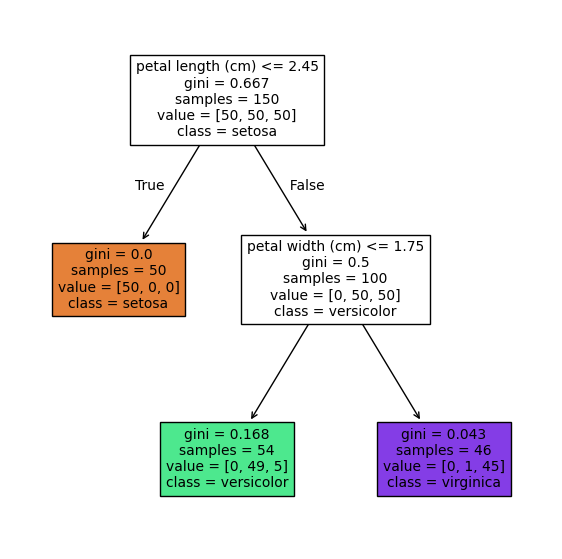

In [ ]:
from sklearn.tree import DecisionTreeClassifier
tree_clf = DecisionTreeClassifier(max_depth = 2)        # depth = log2(m)，m是训练数据的量
tree_clf.fit(X, y)                                      # 训练决策树

from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

plt.figure(figsize=(7, 7))                            # 画决策树结构图并拉开方块之间的空间

plot_tree(
    tree_clf,
    feature_names=iris.feature_names[2:],
    class_names=iris.target_names,
    filled=True,
    fontsize=10
)
plt.show()

tree_clf.predict_proba([[5, 1.5]])      # use the trained tree model to predict the probability that this instance belongs to each class (具体计算方式在纸质笔记本上)
tree_clf.predict([[5, 1.5]])            # use the trained tree model to predict which class this instance belongs

Here is a brief explanation of how to read the decision tree structure graph:

Petal length <= ... is the decision boundary for this node, which splits the samples into two child nodes.

Gini represents Gini impurity, which measures how mixed or "impure" the samples at this node are. A value of gini = 0 means all samples at this node belong to the same class.

samples indicates the total number of samples at this node.

Value is an array showing the distribution of classes at this node, formatted as: [# of samples from Class 1, ..., # of samples from Class n].


There are some hyperparameters in DecisionTreeClassifier() to avoid overfitting: max_depth, min_samples_split, min_samples_leaf, max_features (max # of features evaluated for splitting at each node).

## Decision Tree regression:

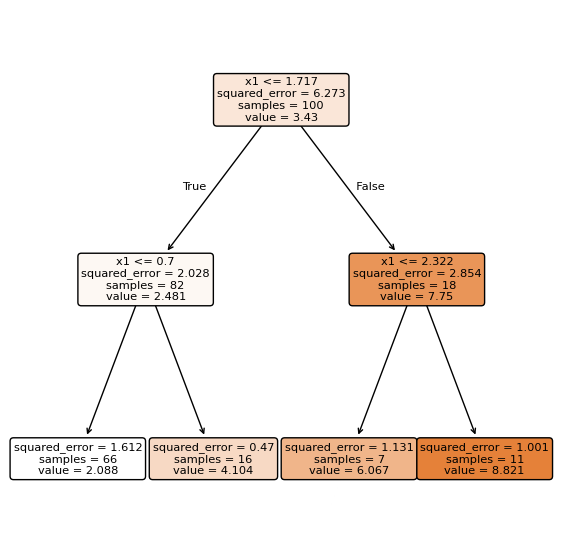

In [32]:
import numpy as np
m=100
X = 6 * np.random.rand(m, 1) - 3
y = 0.5 * X**2 + X + 2 + np.random.randn(m, 1)

from sklearn.tree import DecisionTreeRegressor
tree_reg = DecisionTreeRegressor(max_depth=2)
tree_reg.fit(X, y)

plt.figure(figsize = (7,7))
plot_tree(
    tree_reg,
    feature_names=["x1"],
    filled=True,
    rounded=True
)
plt.show()

Brief explanation of decision tree regressor:

x1 = ... is the decision making process at a given node. If there are multiple attributes, x1 may not be the only attribute used for splitting.

usually decision tree regressor uses MSE as the standard to determine the optimal feature and threshold for splitting. MSE measures the variance of the training instances at a given node.

value is the mean of the target values of all training instances that reach that node.

It is also important to regularize decision tree regressor to avoid overfitting. Two useful hyperparameters are: max_depth and min_samples_leaf. They can help to keep the model reasonably simple while maintaining useful information.